# Figure 6 Supplement 1: Phase-dependent effects on somatic excitability with reversed rhythm locations

This analysis examines action potential threshold and membrane voltage modulation when the spatial targeting of beta and gamma rhythmic inhibition is reversed. Beta rhythmic inhibition (16 Hz) is delivered to the perisomatic region (<100 µm from soma), while gamma rhythmic inhibition (64 Hz) is delivered to distal dendrites (>100 µm from soma). This reversal tests whether the effectiveness of rhythmic inhibition depends on where it impinges upon the neuron.

The simulations include:
1. Beta (16 Hz) rhythmic inhibition delivered perisomatically
2. Gamma (64 Hz) rhythmic inhibition delivered to distal dendrites  
3. Poisson (non-rhythmic) inhibition as a control

We calculate voltage threshold for action potentials and membrane voltage distributions, stratified by the phase (peak or trough) of each inhibitory rhythm. As reported in the paper, swapping the locations of beta and gamma rhythms diminishes their effectiveness and lowers overall excitability. Gamma rhythmic inhibition on the dendrites has minimal impact on action potential threshold but shifts the somatic membrane potential more negative. Beta rhythmic inhibition delivered to the soma raises the action potential threshold and hyperpolarizes the membrane potential during the peak phase.

In [5]:
import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.load_spike_h5 import load_spike_h5
from src.load_v_h5 import load_v_h5
from src.load_axcurrent_csv import load_axcurrent_csv
from src.count_dendevt_files import count_dendevt_files

## 1.0 Analysis parameters

This section defines the parameters for analyzing somatic excitability under reversed rhythm locations. The analysis measures action potential voltage threshold and membrane voltage distributions as a function of the phase of beta and gamma rhythmic inhibition delivered to opposite dendritic compartments from their normal targeting.

### 1.1 Simulation constants and analysis windows

Sampling rate is 10 samples per millisecond. Voltage bins range from -80 to -40 mV in 0.5 mV increments to capture action potential threshold distributions. The simulation window spans 150 seconds (1,500,000 samples).

In [6]:
samps_per_ms = 10 
edges_v = np.arange(-80,-40,0.5)
edges_i = np.linspace(-3,3,160)
sim_win = [0, 1500000] # beginning and start points of simulation in samples

### 1.2 List files to be processed

Simulation files for three conditions are specified:
1. **16 Hz perisomatic inhibition**: Beta rhythm delivered to soma and proximal dendrites (<100 µm)
2. **64 Hz distal dendritic inhibition**: Gamma rhythm delivered to distal dendrites (>100 µm)  
3. **Poisson inhibition**: Non-rhythmic control condition with the same mean inhibitory rate

Each simulation includes dendritic spike event times (Ca²⁺, Na⁺, NMDA), somatic action potentials, and membrane voltage recordings.

In [7]:
# locate simulation files
root_16_dir = 'D:\\DendCompOscPublic\\output_16Hz_on_soma_dom_20p\\'
sim_16_dict = {'SimName': 'output_16Hz_on_soma_dom',
               'RootDir': root_16_dir,
               'CaFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_ca.csv',
               'NaFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_na.csv',
               'NMDAFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_nmda.csv',
               'APFile': root_16_dir + 'spikes.h5',
               'InhProxFile': root_16_dir + 'prox_inh_stim_spikes.h5',
               'InhDistFile': root_16_dir + 'dist_inh_stim_spikes.h5', 
               'VMemFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_soma_v.csv'}

root_64_dir = 'D:\\DendCompOscPublic\\output_64Hz_on_dends_dom_40p\\'
sim_64_dict = {'SimName': 'output_64Hz_on_dends',
               'RootDir': root_64_dir,
               'CaFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_ca.csv',
               'NaFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_na.csv',
               'NMDAFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_nmda.csv',
               'APFile': root_64_dir + 'spikes.h5',
               'InhProxFile': root_64_dir + 'prox_inh_stim_spikes.h5',
               'InhDistFile': root_64_dir + 'dist_inh_stim_spikes.h5', 
               'VMemFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_soma_v.csv'}

root_pois_dir = 'D:\\DendCompOscPublic\\output_allpoisson\\'
sim_pois_dict = {'SimName': 'output_allpoisson',
               'RootDir': root_pois_dir,
               'CaFile': root_pois_dir + 'output_allpoisson_ca.csv',
               'NaFile': root_pois_dir + 'output_allpoisson_na.csv',
               'NMDAFile': root_pois_dir + 'output_allpoisson_nmda.csv',
               'APFile': root_pois_dir + 'spikes.h5',
               'VMemFile': root_pois_dir + 'output_allpoisson_soma_v.csv'}



## 2.0 Phase-stratified analysis of action potential threshold and membrane voltage

This section analyzes how the reversed targeting of rhythmic inhibition affects somatic excitability. We measure cumulative probability distributions of action potential voltage threshold and membrane voltage distributions, stratified by the phase of the inhibitory rhythm (peak vs. trough). According to the paper, this reversed configuration substantially alters the mechanisms of modulation compared to the standard targeting.

### 2.1 Generate phase time series for each rhythm

Sinusoidal phase series are generated for the 16 Hz (beta) and 64 Hz (gamma) rhythms to categorize timepoints as occurring during peak (positive phase, higher inhibition) or trough (negative phase, lower inhibition). These phase labels allow stratification of action potentials and membrane voltage measurements.

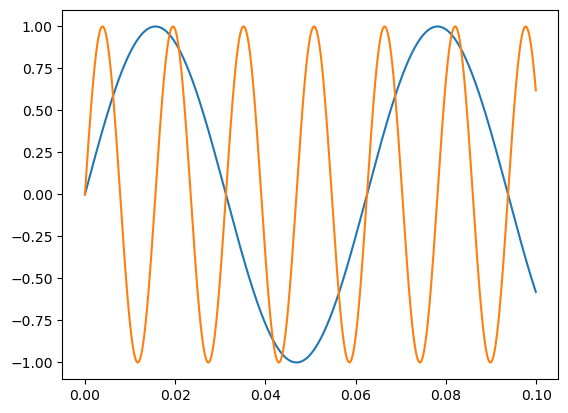

In [8]:
# generate phase time series for inhibitory afferents
t_ser = np.arange(sim_win[0], sim_win[1], 1) / 10000 # seconds
sin_16_ser = np.sin(t_ser*16*2*np.pi)
sin_64_ser = np.sin(t_ser*64*2*np.pi)

fig, ax = plt.subplots()
ax.plot(t_ser[0:1000],sin_16_ser[0:1000])
ax.plot(t_ser[0:1000],sin_64_ser[0:1000])
plt.show()

### 2.2 Calculate action potential threshold voltage and membrane voltage distributions

Action potential threshold is defined as the membrane voltage 1 ms prior to each somatic spike. For each rhythm condition, spikes are separated by phase (peak vs. trough), and cumulative probability distributions are calculated. Additionally, membrane voltage distributions are computed for each phase to reveal how the rhythms modulate somatic depolarization.

As described in the paper, gamma rhythmic inhibition delivered to distal dendrites has minimal or no impact on action potential threshold, but shifts the somatic membrane potential more negative. This hyperpolarization is not phase-dependent and likely reflects an overall decrease in dendritic spikes that supply excitatory drive to the soma (NMDA: -26.1%, Na⁺: -12.2%, Ca²⁺: -39.9%). By contrast, beta rhythmic inhibition delivered perisomatically raises the action potential threshold and hyperpolarizes the membrane potential during the peak phase, also reducing dendritic spike incidence (NMDA: -17.1%, Na⁺: -11.5%, Ca²⁺: -7.6%).

In [11]:
# probability of action potentials by membrane voltage
def ap_prob_func(spk, v, edges):
    null_hist = np.histogram(v, edges)
    spk_hist = np.histogram(v[spk-10], edges)
    spk_cum_prob = np.nancumsum(spk_hist[0]/null_hist[0])
    return {'null': null_hist[0], 'spk': spk_hist[0], 'prob': spk_cum_prob}

def thresh_files_func(sim_dict, sin_ser):
    spk_prob = {'v': {}, 'i_apic': {}, 'i_basal': {}}

    # split action potentials based on phase of rhythm
    spk_t = load_spike_h5(sim_dict['APFile'])
    p_inds = np.where(sin_ser >= 0)
    t_inds = np.where(sin_ser < 0)
    spk_t_p = np.intersect1d(spk_t, p_inds)
    spk_t_t = np.intersect1d(spk_t, t_inds)
    
    # load soma voltage from CSV file
    mem_v = pd.read_csv(sim_dict['VMemFile'])['voltage_mV'].values

    # calculate action potential probability by voltage for each phase
    spk_prob['v']['p'] = ap_prob_func(spk_t_p, mem_v, edges_v)
    spk_prob['v']['t'] = ap_prob_func(spk_t_t, mem_v, edges_v)

    # membrane voltage distribution by phase
    spk_prob['v']['p']['dist'] = np.histogram(mem_v[p_inds], edges_v)[0]
    spk_prob['v']['t']['dist'] = np.histogram(mem_v[t_inds], edges_v)[0]

    return spk_prob

def thresh_files_pois_func(sim_dict):
    spk_prob = {'v': {}, 'i_apic': {}, 'i_basal': {}}

    # split action potentials based on phase of rhythm
    spk_t = load_spike_h5(sim_dict['APFile'])
   
    # load soma voltage from CSV file
    mem_v = pd.read_csv(sim_dict['VMemFile'])['voltage_mV'].values

    # calculate action potential probability by voltage
    spk_prob['v']['pois'] = ap_prob_func(spk_t, mem_v, edges_v)
   
    # membrane voltage distribution
    spk_prob['v']['pois']['dist'] = np.histogram(mem_v, edges_v)[0]

    return spk_prob

In [12]:
# process the 16 Hz distal dendritic inhibition simulation
ph16_prob = thresh_files_func(sim_16_dict, sin_16_ser)

# process the 64 Hz proximal dendritic/somatic inhibition simulation
ph64_prob = thresh_files_func(sim_64_dict, sin_64_ser)

# process the poisson inhibition simulation
pois_prob = thresh_files_pois_func(sim_pois_dict)

C:\Users\dbh60\AppData\Local\Temp\ipykernel_28392\1789278475.py:5: RuntimeWarning: invalid value encountered in divide
  spk_cum_prob = np.nancumsum(spk_hist[0]/null_hist[0])
C:\Users\dbh60\AppData\Local\Temp\ipykernel_28392\1789278475.py:5: RuntimeWarning: invalid value encountered in divide
  spk_cum_prob = np.nancumsum(spk_hist[0]/null_hist[0])


### 2.3 Visualization of action potential threshold and membrane voltage modulation

Plots display cumulative probability distributions of action potential voltage threshold (left panels) and membrane voltage distributions (right panels) for beta (16 Hz) and gamma (64 Hz) rhythmic inhibition with reversed spatial targeting. Red lines indicate peak phase (maximal inhibition), blue lines indicate trough phase (minimal inhibition), and black lines show the Poisson control condition. These visualizations reveal that swapping the locations of beta and gamma rhythms diminishes their phase-dependent effectiveness compared to standard targeting.

In [13]:
# plotting functions
# set meas to 'v' for voltage, and 'i' for current
def ap_prob_ph_plot(ph_prob, ax, meas='v'):
        if meas=='v':
                edges = edges_v[:-1]
        elif meas=='i_apic' or meas=='i_basal':
                edges = edges_i[:-1]
        
        ax.plot(edges, ph_prob[meas]['p']['prob']/np.max(ph_prob[meas]['p']['prob']),color='r')
        ax.plot(edges, ph_prob[meas]['t']['prob']/np.max(ph_prob[meas]['t']['prob']),color='b')
        ax.plot(edges, pois_prob[meas]['pois']['prob']/np.max(pois_prob[meas]['pois']['prob']),color='k')

def meas_prob_ph_plot(ph_prob, ax, meas='v'):
        if meas=='v':
                edges = edges_v[:-1]
        elif meas=='i_apic' or meas=='i_basal':
                edges = edges_i[:-1]

        ax.plot(edges, ph_prob[meas]['p']['dist']/np.max(ph_prob[meas]['p']['dist']),color='r')
        ax.plot(edges, ph_prob[meas]['t']['dist']/np.max(ph_prob[meas]['t']['dist']),color='b')
        ax.plot(edges, pois_prob[meas]['pois']['dist']/np.max(pois_prob[meas]['pois']['dist']),color='k')

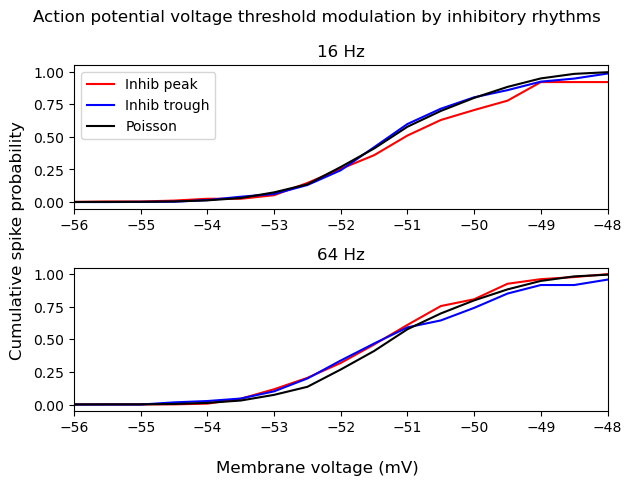

In [14]:
# Action potential probabilities by membrane voltage and phase
fig, ax = plt.subplots(2,1,sharey=True)
ap_prob_ph_plot(ph16_prob, ax[0])
ap_prob_ph_plot(ph64_prob, ax[1])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
ax[0].set_xlim([-56, -48])
ax[1].set_xlim([-56, -48])
fig.suptitle('Action potential voltage threshold modulation by inhibitory rhythms')
fig.supxlabel('Membrane voltage (mV)')
fig.supylabel('Cumulative spike probability')
ax[0].legend(('Inhib peak', 'Inhib trough', 'Poisson'))
plt.tight_layout()


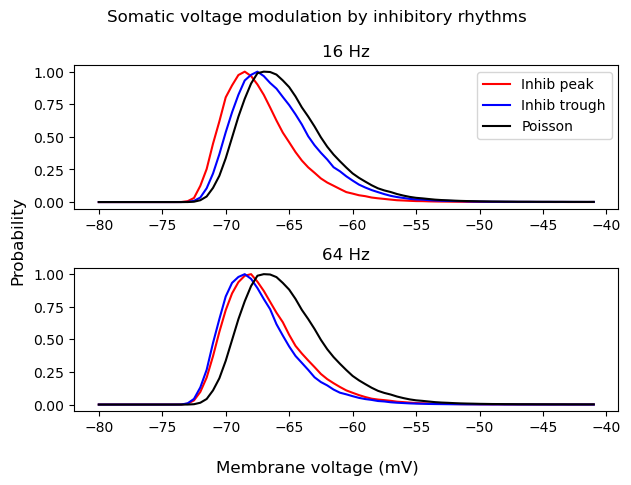

In [15]:
# Membrane voltage by phase
fig, ax = plt.subplots(2,1,sharey=True)
meas_prob_ph_plot(ph16_prob, ax[0])
meas_prob_ph_plot(ph64_prob, ax[1])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
fig.suptitle('Somatic voltage modulation by inhibitory rhythms')
fig.supxlabel('Membrane voltage (mV)')
fig.supylabel('Probability')
ax[0].legend(('Inhib peak', 'Inhib trough', 'Poisson'))
plt.tight_layout()
